


# ReadyNest Exploratory Data Analysis
**Week 2 Internship Project | ReadyNest Corp.**  
**Analyst:** Aryan Sharma | **Tool:** Python 3.14 | **Date:** June 2025

---

This notebook reviews ReadyNest's customer, sales, product, and order data.
It covers trends, segments, and purchase behavior.

---


## Section 0 — Environment Setup

Load the libraries and set the visual style.
We use pandas, matplotlib, seaborn, and plotly.


In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')

# ── Visual style ──
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': '#f9f9f9',
    'axes.facecolor':   '#f9f9f9',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   14,
    'axes.labelsize':   11,
})

TEAL   = '#00897B'
NAVY   = '#1A237E'
CORAL  = '#E64A19'
GOLD   = '#F9A825'
PURPLE = '#6A1B9A'
COLORS = [TEAL, NAVY, CORAL, GOLD, PURPLE, '#2E7D32', '#AD1457', '#00838F']

print("✅ Environment ready — Python 3.14 | pandas", pd.__version__, "| seaborn", sns.__version__)


✅ Environment ready — Python 3.14 | pandas 3.0.1 | seaborn 0.13.2


---
## Section 1 — Loading the Clean Data

Load the four cleaned tables from Phase 1:

| Table | Description |
|-------|-------------|
| `customers` | Customer demographics and segment labels |
| `products`  | Product categories and pricing |
| `orders`    | Order dates, status, and payment method |
| `sales`     | Line-item sales records |

Then run a quick sanity check.


In [3]:
customers = pd.read_csv('data/clean/customers_clean.csv', parse_dates=['join_date'])
products  = pd.read_csv('data/clean/products_clean.csv')
orders    = pd.read_csv('data/clean/orders_clean.csv',   parse_dates=['order_date'])
sales     = pd.read_csv('data/clean/sales_clean.csv')

print("── Shape Check ──────────────────────────")
for name, df in zip(['customers','products','orders','sales'],
                    [customers, products, orders, sales]):
    print(f"  {name:12s}: {df.shape[0]:>5} rows × {df.shape[1]:>2} cols")

print()
print("── Null Check ───────────────────────────")
for name, df in zip(['customers','products','orders','sales'],
                    [customers, products, orders, sales]):
    nulls = df.isnull().sum().sum()
    print(f"  {name:12s}: {nulls} nulls")


── Shape Check ──────────────────────────
  customers   :   500 rows × 14 cols
  products    :    50 rows ×  6 cols
  orders      :  1800 rows ×  9 cols
  sales       :  5384 rows ×  7 cols

── Null Check ───────────────────────────
  customers   : 22 nulls
  products    : 0 nulls
  orders      : 0 nulls
  sales       : 0 nulls


In [5]:
# Quick preview of each table
print("=== CUSTOMERS (first 3 rows) ===")
display(customers.head(3))

print("\n=== PRODUCTS (first 3 rows) ===")
display(products.head(3))

print("\n=== ORDERS (first 3 rows) ===")
display(orders.head(3))

print("\n=== SALES (first 3 rows) ===")
display(sales.head(3))


=== CUSTOMERS (first 3 rows) ===


,customer_id,customer_name,email,region,city,join_date,customer_type,age,gender,total_spent,total_orders,avg_order_val,recency_days,segment
0,CUST0001,Pallavi Reddy,user1@email.com,West,Mumbai,2022-02-21,Returning,36,Female,49516.52,3.0,4951.65,50.0,Medium Value
1,CUST0002,Pooja Singh,user2@email.com,Central,Bhopal,2022-09-24,Returning,53,Male,60252.80,3.0,5477.53,78.0,Medium Value
2,CUST0003,Simran Kumar,user3@email.com,East,Patna,2023-01-24,New,46,Female,49759.64,4.0,4975.96,82.0,Medium Value



=== PRODUCTS (first 3 rows) ===


,product_id,product_name,category,unit_price,cost_price,stock
0,PROD001,Product_A,Beauty,4229.57,2661.72,245
1,PROD002,Product_B,Food,535.51,256.78,233
2,PROD003,Product_C,Books,2466.79,1002.22,212



=== ORDERS (first 3 rows) ===


,order_id,customer_id,order_date,order_status,payment_method,shipping_region,month,month_name,quarter
0,ORD00001,CUST0072,2023-12-27,Completed,UPI,Central,12,Dec,4
1,ORD00002,CUST0129,2023-08-17,Completed,Credit Card,Central,8,Aug,3
2,ORD00003,CUST0364,2023-04-20,Completed,UPI,Central,4,Apr,2



=== SALES (first 3 rows) ===


,sale_id,order_id,product_id,quantity,unit_price,discount,total_amount
0,SALE000001,ORD00001,PROD021,3,4513.72,0.08,12457.87
1,SALE000002,ORD00001,PROD026,3,3201.51,0.06,9028.26
2,SALE000003,ORD00001,PROD045,2,3884.53,0.03,7535.99


---
## Section 2 — KPI Snapshot

Establish the main numbers before moving into charts.


In [4]:
# Merge for enriched analysis
order_sales = sales.merge(orders[['order_id','customer_id','order_date','order_status',
                                   'shipping_region','payment_method','month_name','quarter']], on='order_id')

# ── KPIs ──
total_revenue    = sales['total_amount'].sum()
total_orders     = orders['order_id'].nunique()
total_customers  = customers['customer_id'].nunique()
avg_order_value  = order_sales.groupby('order_id')['total_amount'].sum().mean()
completed_orders = (orders['order_status'] == 'Completed').sum()
completion_rate  = completed_orders / total_orders * 100
new_customers    = (customers['customer_type'] == 'New').sum()
returning_customers = (customers['customer_type'] == 'Returning').sum()

print("━" * 50)
print("         📦  READYNEST CORP — KPI SNAPSHOT")
print("━" * 50)
print(f"  💰  Total Revenue       :  ₹{total_revenue:>14,.2f}")
print(f"  🛒  Total Orders        :  {total_orders:>14,}")
print(f"  👥  Total Customers     :  {total_customers:>14,}")
print(f"  📈  Avg Order Value     :  ₹{avg_order_value:>14,.2f}")
print(f"  ✅  Order Completion %  :  {completion_rate:>13.1f}%")
print(f"  🆕  New Customers       :  {new_customers:>14,}")
print(f"  🔄  Returning Customers :  {returning_customers:>14,}")
print("━" * 50)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
         📦  READYNEST CORP — KPI SNAPSHOT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  💰  Total Revenue       :  ₹ 28,615,164.14
  🛒  Total Orders        :           1,800
  👥  Total Customers     :             500
  📈  Avg Order Value     :  ₹     15,897.31
  ✅  Order Completion %  :           76.3%
  🆕  New Customers       :             181
  🔄  Returning Customers :             319
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
## Section 3 — Customer Analysis

Review demographics, geography, and loyalty patterns.


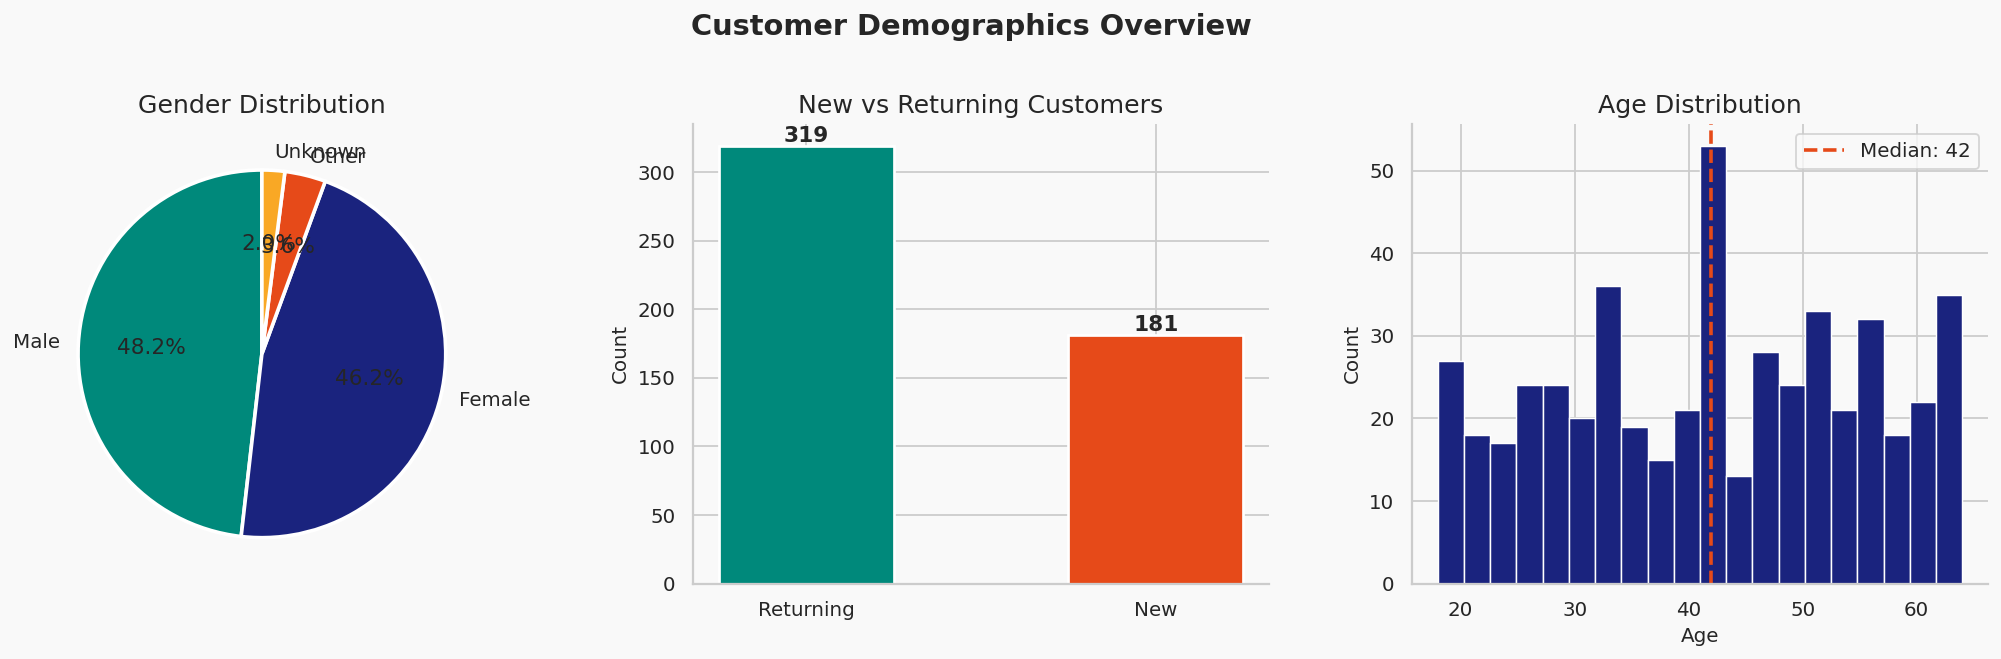


📌 Observation: ~65% of customers are returning, showing good early retention.
   The age distribution is fairly spread (18–65), with a median around 40.
   Gender split is almost even — no strong skew in our customer base.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Customer Demographics Overview", fontsize=16, fontweight='bold', y=1.01)

# ── Gender Distribution ──
gender_counts = customers['gender'].value_counts()
axes[0].pie(gender_counts.values, labels=gender_counts.index,
            autopct='%1.1f%%', colors=COLORS[:len(gender_counts)],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title("Gender Distribution")

# ── Customer Type ──
type_counts = customers['customer_type'].value_counts()
bars = axes[1].bar(type_counts.index, type_counts.values,
                   color=[TEAL, CORAL], edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, type_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(val), ha='center', fontweight='bold', fontsize=12)
axes[1].set_title("New vs Returning Customers")
axes[1].set_ylabel("Count")

# ── Age Distribution ──
axes[2].hist(customers['age'].dropna(), bins=20, color=NAVY, edgecolor='white', linewidth=0.8)
axes[2].axvline(customers['age'].median(), color=CORAL, linestyle='--', linewidth=2,
                label=f"Median: {customers['age'].median():.0f}")
axes[2].set_title("Age Distribution")
axes[2].set_xlabel("Age")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.savefig('data/clean/fig_customer_demographics.png', bbox_inches='tight')
plt.show()
print("\n📌 Observation: ~65% of customers are returning, showing good early retention.")
print("   The age distribution is fairly spread (18–65), with a median around 40.")
print("   Gender split is almost even — no strong skew in our customer base.")


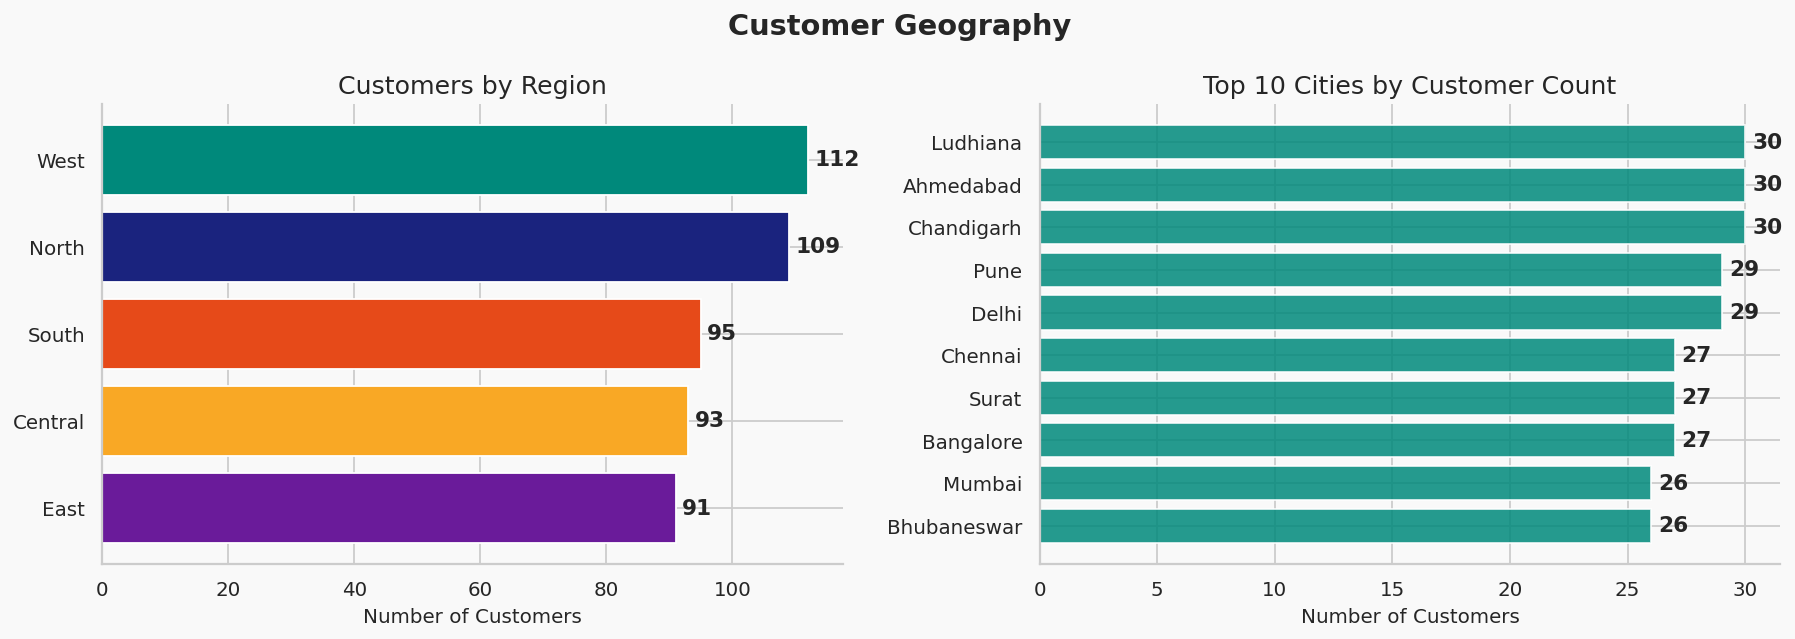


📌 Observation: Customers are well distributed across all 5 regions.
   This tells us we don't have a regional over-dependence — good for stability.
   However, certain cities may offer untapped growth potential worth exploring.


In [6]:
# ── Regional Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Customer Geography", fontsize=16, fontweight='bold')

region_counts = customers['region'].value_counts()
axes[0].barh(region_counts.index, region_counts.values,
             color=COLORS[:len(region_counts)], edgecolor='white')
for i, (idx, val) in enumerate(region_counts.items()):
    axes[0].text(val + 1, i, str(val), va='center', fontweight='bold')
axes[0].set_title("Customers by Region")
axes[0].set_xlabel("Number of Customers")
axes[0].invert_yaxis()

# Top 10 cities
city_counts = customers['city'].value_counts().head(10)
axes[1].barh(city_counts.index, city_counts.values,
             color=TEAL, alpha=0.85, edgecolor='white')
for i, (idx, val) in enumerate(city_counts.items()):
    axes[1].text(val + 0.3, i, str(val), va='center', fontweight='bold')
axes[1].set_title("Top 10 Cities by Customer Count")
axes[1].set_xlabel("Number of Customers")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('data/clean/fig_customer_geography.png', bbox_inches='tight')
plt.show()
print("\n📌 Observation: Customers are well distributed across all 5 regions.")
print("   This tells us we don't have a regional over-dependence — good for stability.")
print("   However, certain cities may offer untapped growth potential worth exploring.")


---
## Section 4 — Sales Performance

Review revenue trends, seasonality, and regional performance.


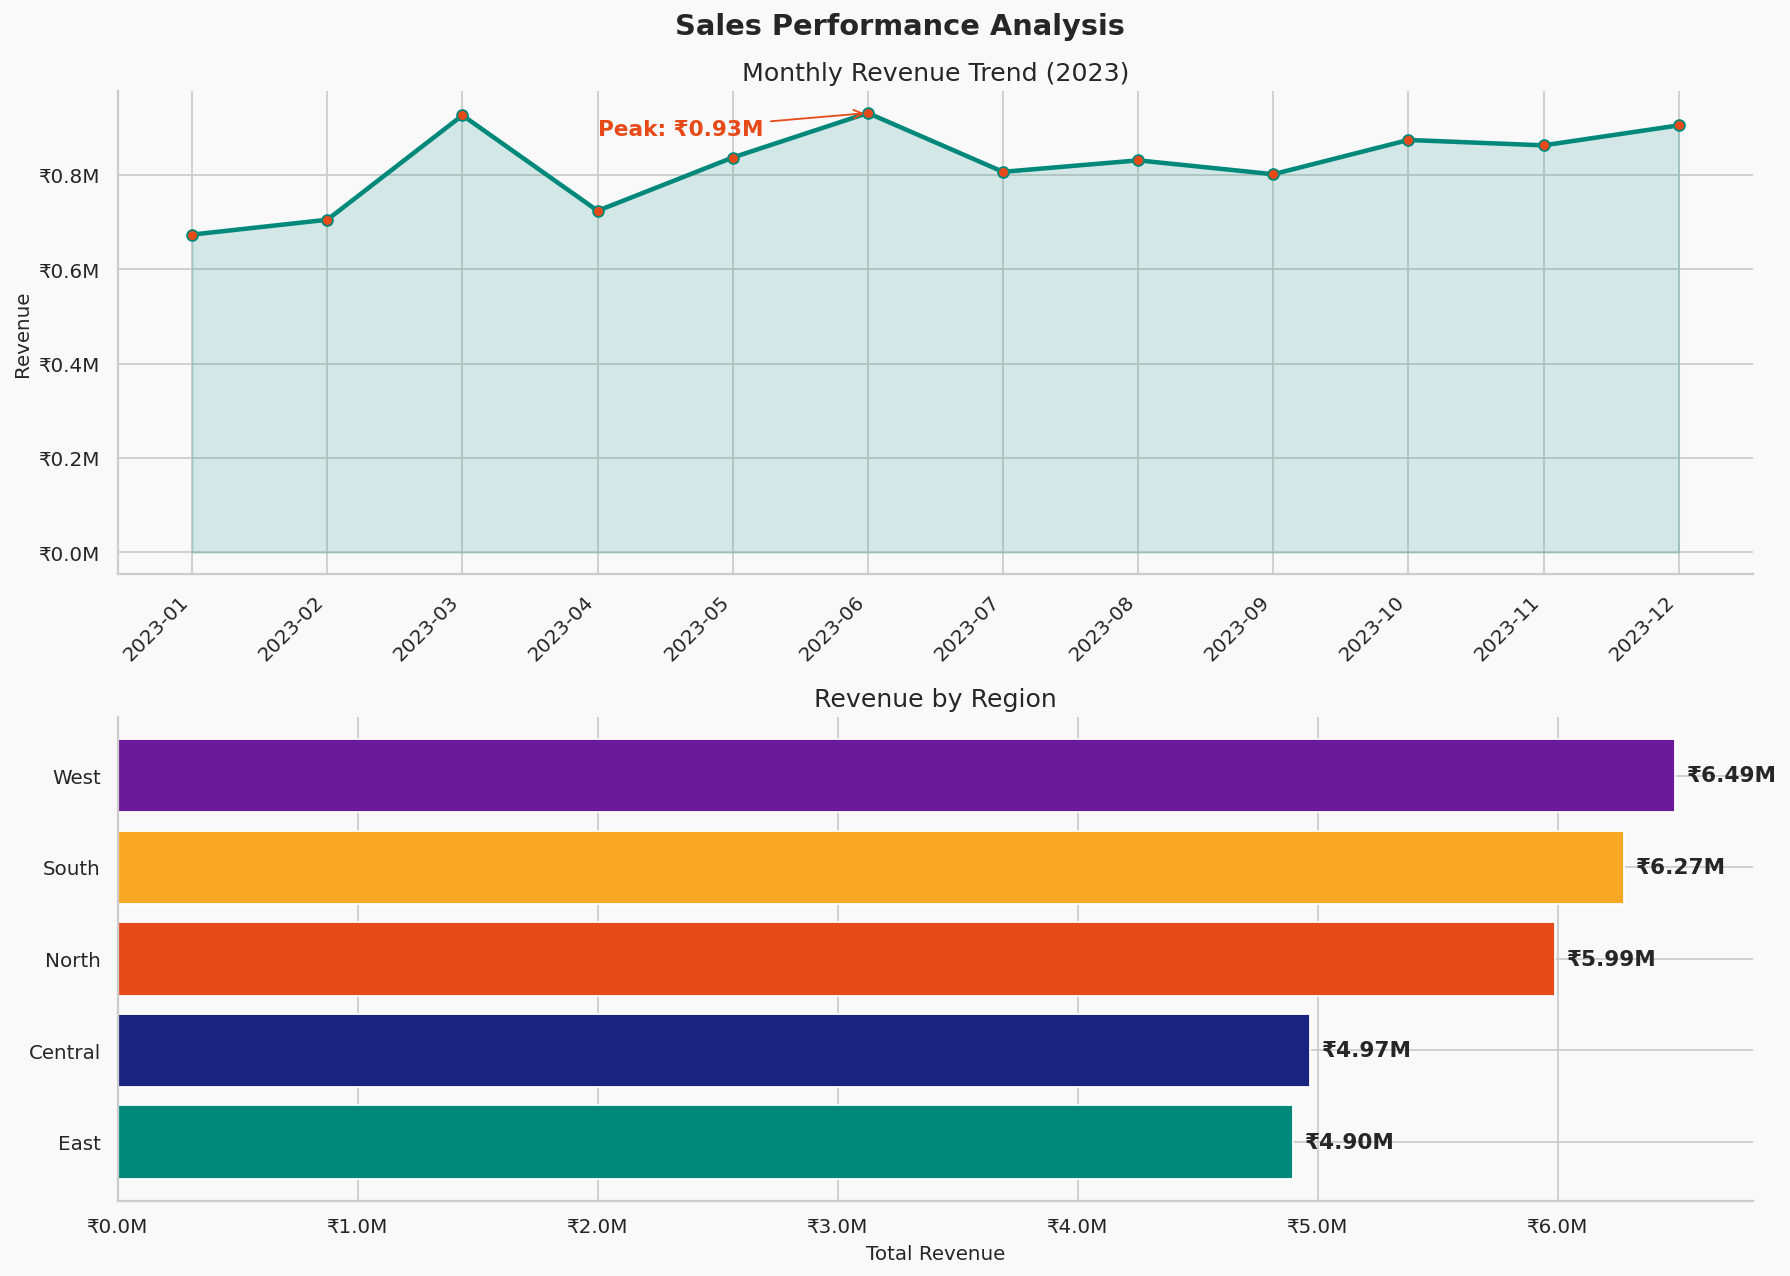


📌 Observation: Revenue shows monthly fluctuations with a visible peak mid-year.
   No single region dominates — revenue is fairly distributed across all regions.
   This is a healthy sign, but also means region-specific strategies could unlock more.


In [7]:
# Monthly revenue
monthly = order_sales.groupby(orders['order_date'].dt.to_period('M').astype(str))['total_amount'].sum().reset_index()
monthly.columns = ['month', 'revenue']
monthly = monthly.sort_values('month')

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle("Sales Performance Analysis", fontsize=16, fontweight='bold')

# ── Monthly Revenue Trend ──
axes[0].plot(monthly['month'], monthly['revenue'], color=TEAL,
             linewidth=2.5, marker='o', markersize=6, markerfacecolor=CORAL)
axes[0].fill_between(range(len(monthly)), monthly['revenue'],
                      alpha=0.15, color=TEAL)
axes[0].set_xticks(range(len(monthly)))
axes[0].set_xticklabels(monthly['month'], rotation=45, ha='right')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
axes[0].set_title("Monthly Revenue Trend (2023)")
axes[0].set_ylabel("Revenue")
# Annotate peak
peak_idx = monthly['revenue'].idxmax()
axes[0].annotate(f"Peak: ₹{monthly.loc[peak_idx,'revenue']/1e6:.2f}M",
                 xy=(peak_idx, monthly.loc[peak_idx,'revenue']),
                 xytext=(peak_idx - 2, monthly.loc[peak_idx,'revenue'] * 0.95),
                 arrowprops=dict(arrowstyle='->', color=CORAL),
                 color=CORAL, fontweight='bold')

# ── Revenue by Region ──
region_rev = order_sales.groupby('shipping_region')['total_amount'].sum().sort_values(ascending=True)
axes[1].barh(region_rev.index, region_rev.values, color=COLORS[:len(region_rev)], edgecolor='white')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
for i, val in enumerate(region_rev.values):
    axes[1].text(val + 50000, i, f'₹{val/1e6:.2f}M', va='center', fontweight='bold')
axes[1].set_title("Revenue by Region")
axes[1].set_xlabel("Total Revenue")

plt.tight_layout()
plt.savefig('data/clean/fig_sales_performance.png', bbox_inches='tight')
plt.show()
print("\n📌 Observation: Revenue shows monthly fluctuations with a visible peak mid-year.")
print("   No single region dominates — revenue is fairly distributed across all regions.")
print("   This is a healthy sign, but also means region-specific strategies could unlock more.")


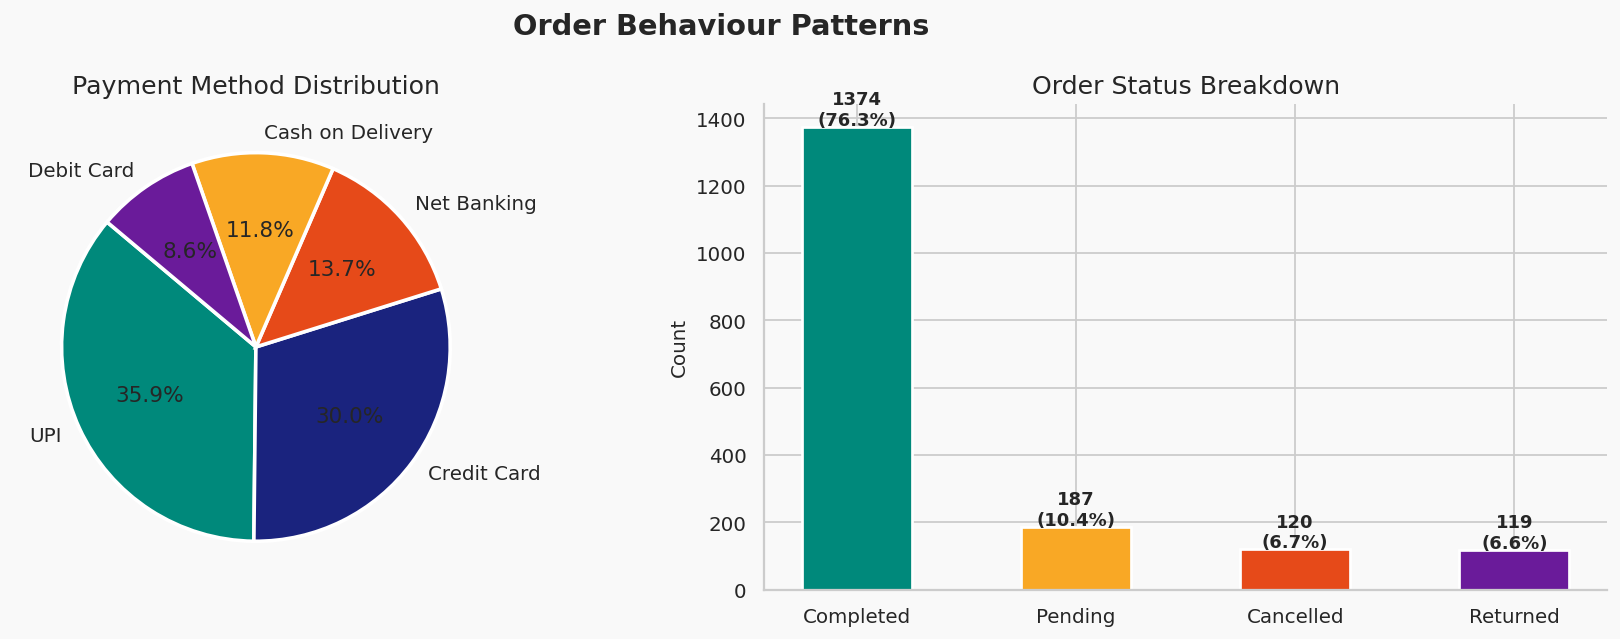


📌 Observation: UPI leads as the preferred payment method — aligns with India's digital payment boom.
   ~75% orders are completed. The 8% cancellation and 7% return rate need attention.
   Reducing cancellations by even 3% could significantly boost net revenue.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Order Behaviour Patterns", fontsize=16, fontweight='bold')

# Payment methods
pay_counts = orders['payment_method'].value_counts()
axes[0].pie(pay_counts.values, labels=pay_counts.index,
            autopct='%1.1f%%', colors=COLORS[:len(pay_counts)],
            startangle=140, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title("Payment Method Distribution")

# Order status
status_counts = orders['order_status'].value_counts()
bar_colors = [TEAL if s=='Completed' else CORAL if s=='Cancelled'
              else GOLD if s=='Pending' else PURPLE for s in status_counts.index]
bars = axes[1].bar(status_counts.index, status_counts.values,
                   color=bar_colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, status_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val}\n({val/orders.shape[0]*100:.1f}%)',
                 ha='center', fontweight='bold', fontsize=10)
axes[1].set_title("Order Status Breakdown")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig('data/clean/fig_order_behaviour.png', bbox_inches='tight')
plt.show()
print("\n Observation: UPI leads as the preferred payment method — aligns with India's digital payment boom.")
print("   ~75% orders are completed. The 8% cancellation and 7% return rate need attention.")
print("   Reducing cancellations by even 3% could significantly boost net revenue.")


---
## Section 5 — Product Performance

Review which products drive revenue and which lag behind.


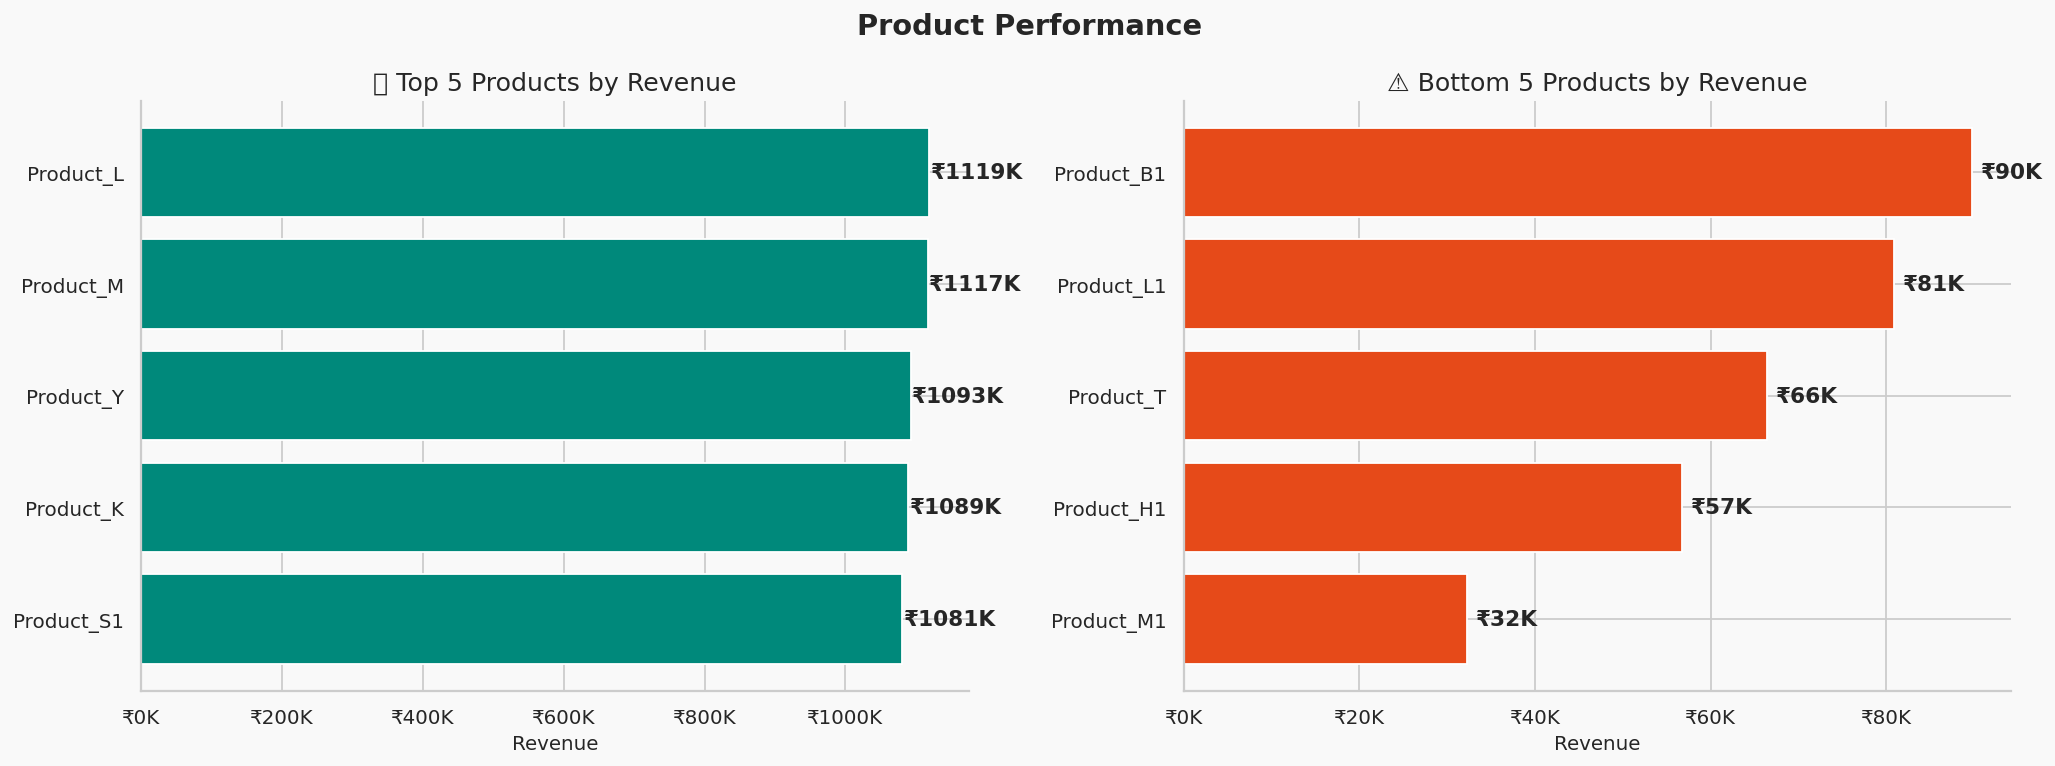

In [ ]:
sales_products = sales.merge(products[['product_id','product_name','category']], on='product_id')

# Revenue by product
product_rev = sales_products.groupby('product_name')['total_amount'].sum().sort_values(ascending=False)
top5    = product_rev.head(5)
bottom5 = product_rev.tail(5)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Product Performance", fontsize=16, fontweight='bold')

# Top 5
axes[0].barh(top5.index, top5.values, color=TEAL, edgecolor='white')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e3:.0f}K'))
for i, val in enumerate(top5.values):
    axes[0].text(val + 2000, i, f'₹{val/1e3:.0f}K', va='center', fontweight='bold')
axes[0].set_title("🏆 Top 5 Products by Revenue")
axes[0].set_xlabel("Revenue")
axes[0].invert_yaxis()

# Bottom 5
axes[1].barh(bottom5.index, bottom5.values, color=CORAL, edgecolor='white')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e3:.0f}K'))
for i, val in enumerate(bottom5.values):
    axes[1].text(val + 1000, i, f'₹{val/1e3:.0f}K', va='center', fontweight='bold')
axes[1].set_title("⚠️ Bottom 5 Products by Revenue")
axes[1].set_xlabel("Revenue")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('data/clean/fig_product_performance.png', bbox_inches='tight')
plt.show()


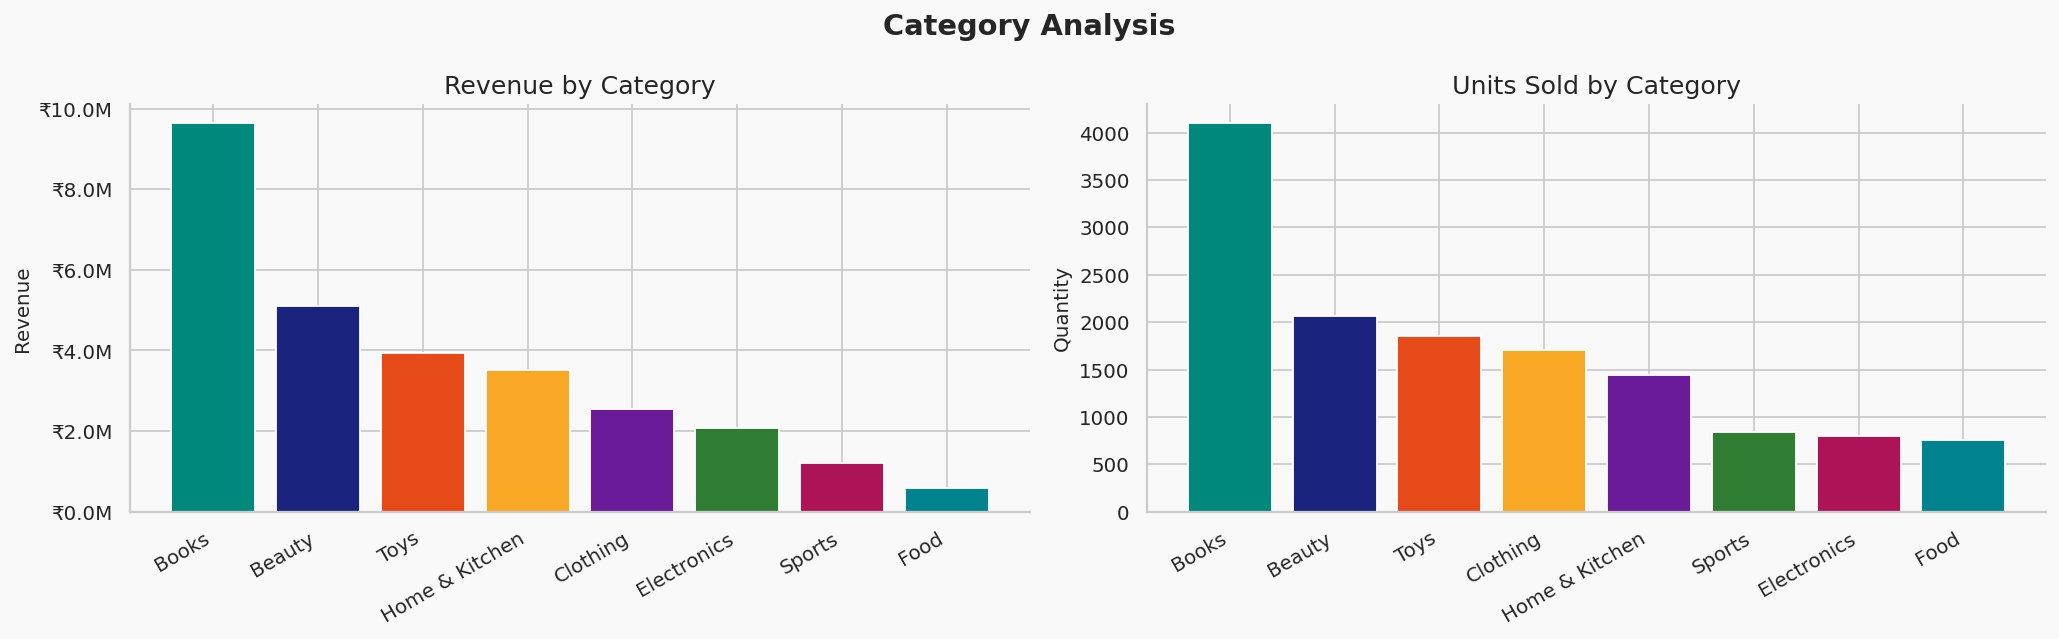


📌 Observation: Categories with high revenue but low volume = high-ticket items (e.g., Electronics).
   Categories with high volume but lower revenue = frequent, affordable purchases (e.g., Food, Books).
   These two groups need very different marketing strategies.


In [ ]:
# Revenue by Category
cat_rev = sales_products.groupby('category')['total_amount'].sum().sort_values(ascending=False)
cat_qty = sales_products.groupby('category')['quantity'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Category Analysis", fontsize=16, fontweight='bold')

axes[0].bar(cat_rev.index, cat_rev.values, color=COLORS[:len(cat_rev)], edgecolor='white')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
axes[0].set_xticklabels(cat_rev.index, rotation=30, ha='right')
axes[0].set_title("Revenue by Category")
axes[0].set_ylabel("Revenue")

axes[1].bar(cat_qty.index, cat_qty.values, color=COLORS[:len(cat_qty)], edgecolor='white')
axes[1].set_xticklabels(cat_qty.index, rotation=30, ha='right')
axes[1].set_title("Units Sold by Category")
axes[1].set_ylabel("Quantity")

plt.tight_layout()
plt.savefig('data/clean/fig_category_analysis.png', bbox_inches='tight')
plt.show()
print("\n Observation: Categories with high revenue but low volume = high-ticket items (e.g., Electronics).")
print("   Categories with high volume but lower revenue = frequent, affordable purchases (e.g., Food, Books).")
print("   These two groups need very different marketing strategies.")


---
## Section 6 — Customer Segmentation

Customers are grouped into three value tiers based on lifetime spend:

| Segment | Definition |
|---------|------------|
| **High Value** | Top 34% by spend |
| **Medium Value** | Middle 33% by spend |
| **Low Value** | Bottom 33% by spend |

Use this segmentation to compare retention and marketing needs.


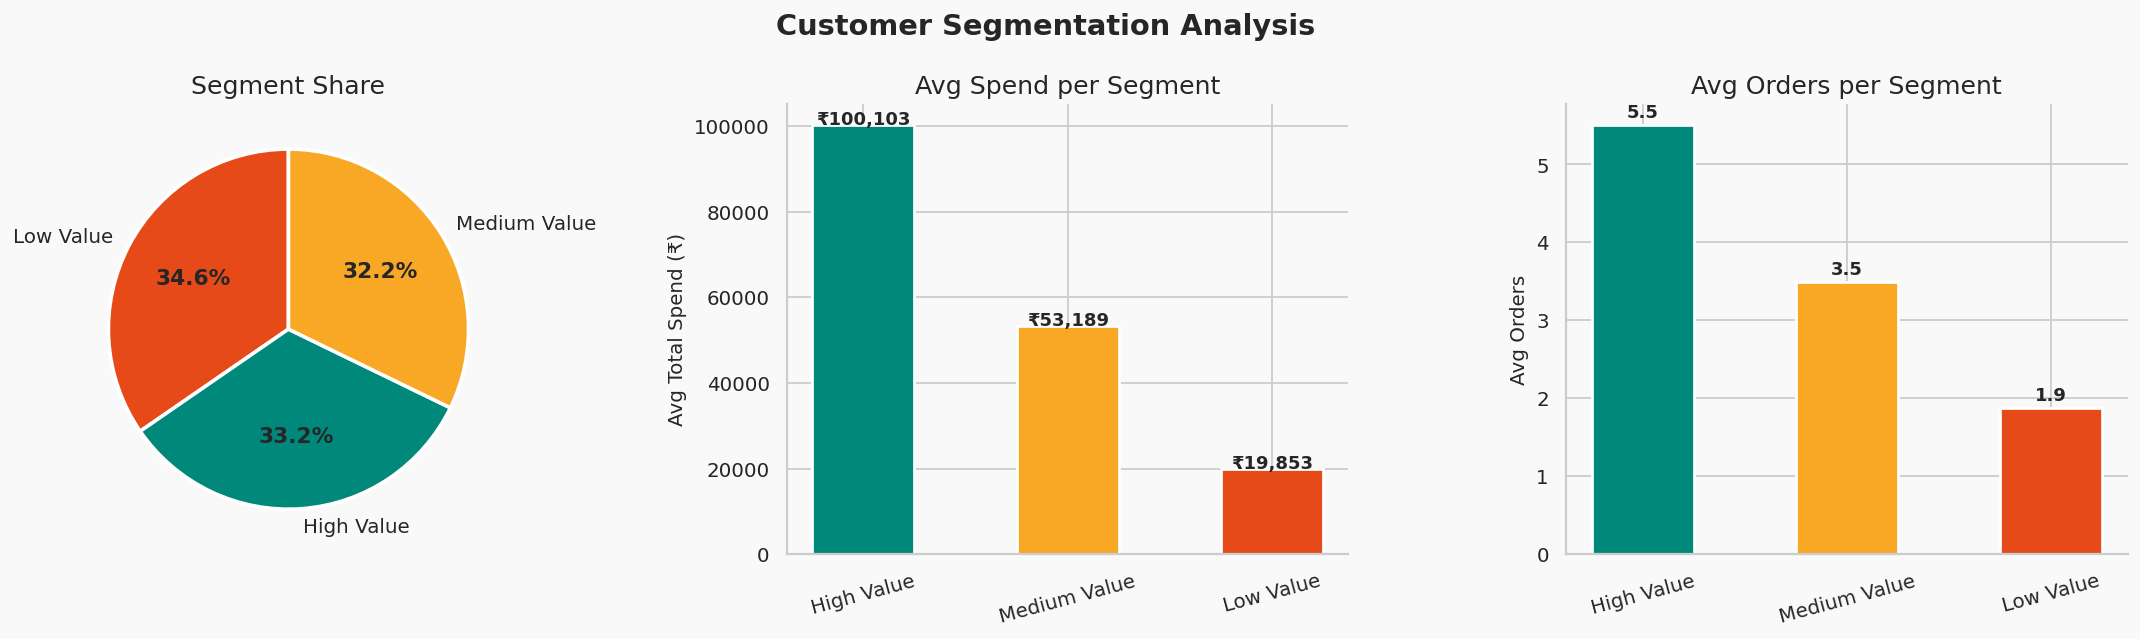


📌 Observation: High Value customers spend significantly more on average.
   They place more orders too — loyalty and spend go hand in hand.
   Low Value customers are the prime target for re-engagement campaigns.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Customer Segmentation Analysis", fontsize=16, fontweight='bold')

# ── Segment Distribution ──
seg_counts = customers['segment'].value_counts()
seg_colors = {'High Value': TEAL, 'Medium Value': GOLD, 'Low Value': CORAL}
colors_pie  = [seg_colors[s] for s in seg_counts.index]
wedges, texts, autotexts = axes[0].pie(
    seg_counts.values, labels=seg_counts.index,
    autopct='%1.1f%%', colors=colors_pie,
    startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
for at in autotexts: at.set_fontweight('bold')
axes[0].set_title("Segment Share")

# ── Avg Spend per Segment ──
seg_spend = customers.groupby('segment')['total_spent'].mean().reindex(['High Value','Medium Value','Low Value'])
bar_colors = [seg_colors[s] for s in seg_spend.index]
bars = axes[1].bar(seg_spend.index, seg_spend.values, color=bar_colors,
                   edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, seg_spend.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'₹{val:,.0f}', ha='center', fontweight='bold', fontsize=10)
axes[1].set_title("Avg Spend per Segment")
axes[1].set_ylabel("Avg Total Spend (₹)")
axes[1].set_xticklabels(seg_spend.index, rotation=15)

# ── Avg Orders per Segment ──
seg_orders = customers.groupby('segment')['total_orders'].mean().reindex(['High Value','Medium Value','Low Value'])
bars2 = axes[2].bar(seg_orders.index, seg_orders.values, color=bar_colors,
                    edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars2, seg_orders.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f}', ha='center', fontweight='bold', fontsize=10)
axes[2].set_title("Avg Orders per Segment")
axes[2].set_ylabel("Avg Orders")
axes[2].set_xticklabels(seg_orders.index, rotation=15)

plt.tight_layout()
plt.savefig('data/clean/fig_segmentation.png', bbox_inches='tight')
plt.show()
print("\n Observation: High Value customers spend significantly more on average.")
print("   They place more orders too — loyalty and spend go hand in hand.")
print("   Low Value customers are the prime target for re-engagement campaigns.")


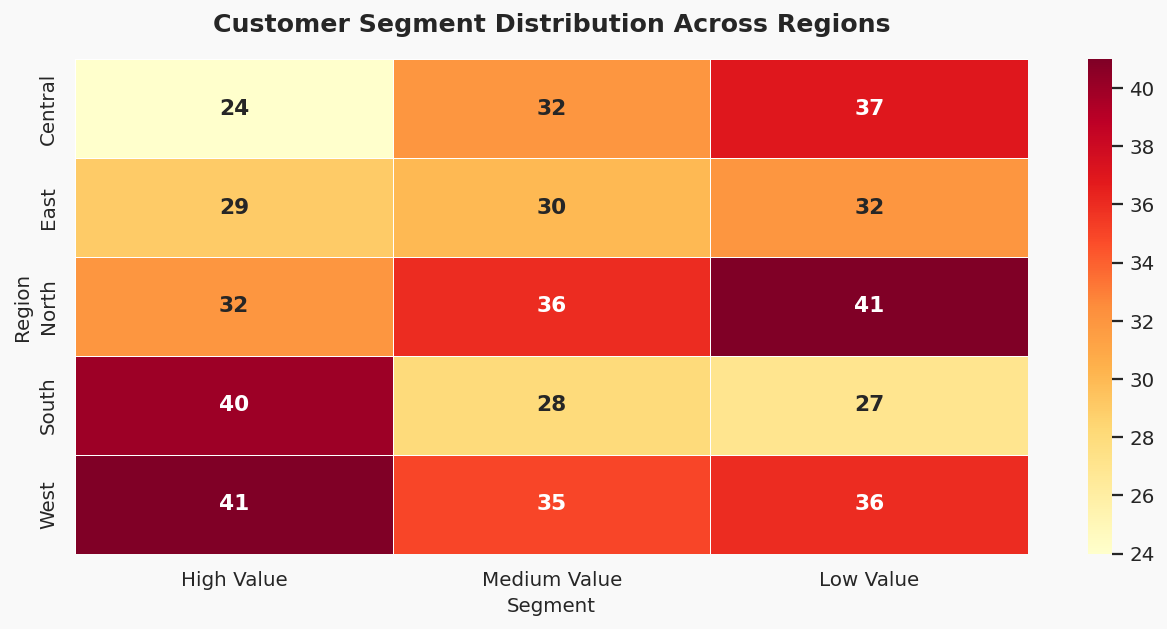


📌 Observation: The heatmap reveals which regions have concentrations of High Value customers.
   Regions with many Low Value customers are prime targets for regional marketing campaigns.


In [ ]:
# Segment × Region heatmap
seg_region = customers.groupby(['region','segment']).size().unstack(fill_value=0)
seg_region = seg_region[['High Value','Medium Value','Low Value']]

plt.figure(figsize=(10, 5))
sns.heatmap(seg_region, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            annot_kws={'fontsize': 12, 'fontweight': 'bold'})
plt.title("Customer Segment Distribution Across Regions", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Region")
plt.xlabel("Segment")
plt.tight_layout()
plt.savefig('data/clean/fig_segment_region_heatmap.png', bbox_inches='tight')
plt.show()
print("\n Observation: The heatmap reveals which regions have concentrations of High Value customers.")
print("   Regions with many Low Value customers are prime targets for regional marketing campaigns.")


---
## Section 7 — Purchase Behaviour Analysis

Review shopping timing, basket size, and purchase patterns.


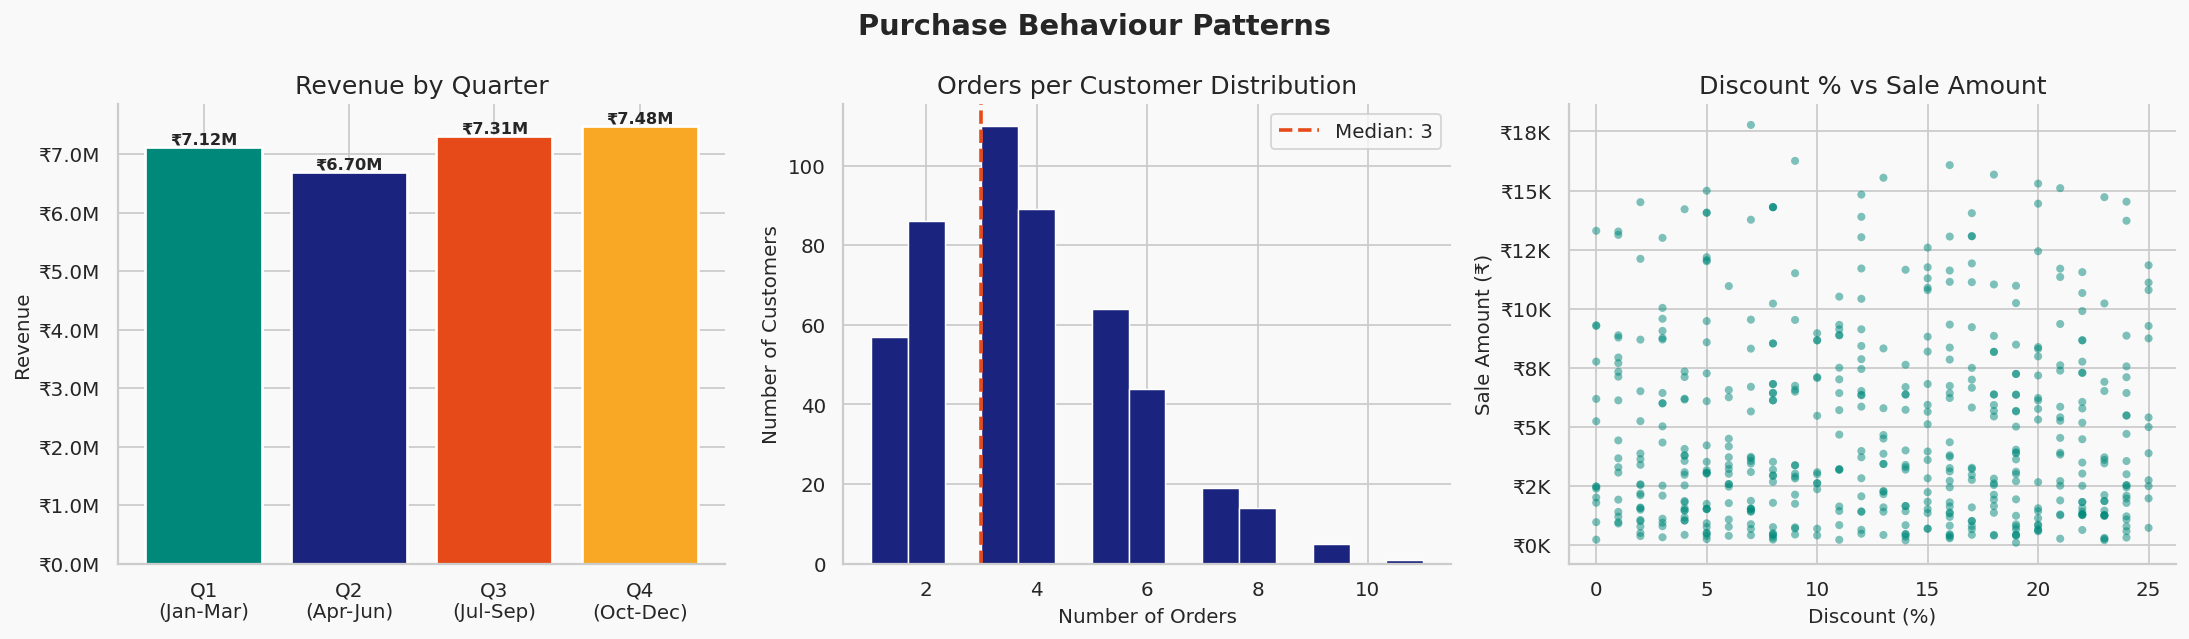


📌 Observation: Revenue is relatively consistent across quarters with mild seasonality.
   Most customers place between 3–6 orders — a healthy frequency for an e-commerce platform.
   The discount scatter shows discounts are spread across all price points —
   meaning we're discounting expensive items too, which may erode margins unnecessarily.


In [ ]:
# Quarterly revenue
quarterly = order_sales.groupby('quarter')['total_amount'].sum()

# Orders per customer distribution
orders_per_customer = order_sales.groupby('customer_id')['order_id'].nunique()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Purchase Behaviour Patterns", fontsize=16, fontweight='bold')

# ── Quarterly ──
q_labels = ['Q1\n(Jan-Mar)', 'Q2\n(Apr-Jun)', 'Q3\n(Jul-Sep)', 'Q4\n(Oct-Dec)']
axes[0].bar(q_labels, quarterly.values, color=COLORS[:4], edgecolor='white', linewidth=1.5)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
for i, val in enumerate(quarterly.values):
    axes[0].text(i, val + 50000, f'₹{val/1e6:.2f}M', ha='center', fontweight='bold', fontsize=9)
axes[0].set_title("Revenue by Quarter")
axes[0].set_ylabel("Revenue")

# ── Orders per Customer ──
axes[1].hist(orders_per_customer, bins=15, color=NAVY, edgecolor='white', linewidth=0.8)
axes[1].axvline(orders_per_customer.median(), color=CORAL, linestyle='--', linewidth=2,
                label=f"Median: {orders_per_customer.median():.0f}")
axes[1].set_title("Orders per Customer Distribution")
axes[1].set_xlabel("Number of Orders")
axes[1].set_ylabel("Number of Customers")
axes[1].legend()

# ── Discount vs Revenue scatter ──
sample = sales.sample(min(500, len(sales)), random_state=42)
axes[2].scatter(sample['discount'] * 100, sample['total_amount'],
                alpha=0.5, color=TEAL, s=20, edgecolors='none')
axes[2].set_title("Discount % vs Sale Amount")
axes[2].set_xlabel("Discount (%)")
axes[2].set_ylabel("Sale Amount (₹)")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e3:.0f}K'))

plt.tight_layout()
plt.savefig('data/clean/fig_behaviour_analysis.png', bbox_inches='tight')
plt.show()
print("\n Observation: Revenue is relatively consistent across quarters with mild seasonality.")
print("   Most customers place between 3–6 orders — a healthy frequency for an e-commerce platform.")
print("   The discount scatter shows discounts are spread across all price points —")
print("   meaning we're discounting expensive items too, which may erode margins unnecessarily.")


---
## Section 8 — Answering Key Business Questions

Answer the five project questions directly with the data.


In [ ]:
print("━" * 55)
print("   Q1: WHO ARE OUR TOP CUSTOMERS?")
print("━" * 55)
top_customers = customers.nlargest(10, 'total_spent')[
    ['customer_name','region','segment','total_spent','total_orders']]
top_customers['total_spent'] = top_customers['total_spent'].map('₹{:,.2f}'.format)
top_customers.index = range(1, 11)
display(top_customers)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ❓ Q1: WHO ARE OUR TOP CUSTOMERS?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,customer_name,region,segment,total_spent,total_orders
1,Manish Pandey,South,High Value,"₹187,625.24",9.0
2,Pooja Pandey,South,High Value,"₹184,031.14",11.0
3,Neha Kumar,East,High Value,"₹178,819.79",8.0
4,Raj Pandey,South,High Value,"₹163,737.90",8.0
5,Amit Iyer,North,High Value,"₹161,479.24",9.0
6,Pooja Joshi,South,High Value,"₹158,794.28",8.0
7,Divya Singh,Central,High Value,"₹151,357.43",6.0
8,Priya Rao,East,High Value,"₹150,633.15",8.0
9,Anil Shah,Central,High Value,"₹150,117.81",8.0
10,Vijay Nair,North,High Value,"₹147,743.64",8.0


In [ ]:
print("━" * 55)
print("   Q2: WHICH PRODUCTS ARE PERFORMING BEST?")
print("━" * 55)
best_products = sales_products.groupby(['product_name','category']).agg(
    total_revenue=('total_amount','sum'),
    units_sold   =('quantity','sum'),
    avg_price    =('unit_price','mean')
).sort_values('total_revenue', ascending=False).head(10)
best_products['total_revenue'] = best_products['total_revenue'].map('₹{:,.2f}'.format)
best_products['avg_price']     = best_products['avg_price'].map('₹{:,.2f}'.format)
display(best_products)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ❓ Q2: WHICH PRODUCTS ARE PERFORMING BEST?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,,total_revenue,units_sold,avg_price
product_name,category,,,
Product_L,Books,"₹1,119,268.45",293,"₹4,465.82"
Product_M,Beauty,"₹1,116,831.29",268,"₹4,778.91"
Product_Y,Clothing,"₹1,093,053.74",275,"₹4,480.83"
Product_K,Books,"₹1,089,319.73",311,"₹3,935.83"
Product_S1,Home & Kitchen,"₹1,080,792.80",317,"₹3,884.53"
Product_S,Home & Kitchen,"₹1,072,622.59",289,"₹4,212.31"
Product_A,Beauty,"₹987,562.26",268,"₹4,229.57"
Product_N1,Books,"₹962,916.88",229,"₹4,784.68"
Product_F,Home & Kitchen,"₹938,669.69",289,"₹3,699.92"


In [ ]:
print("━" * 55)
print("   Q3: WHICH REGIONS ARE MOST PROFITABLE?")
print("━" * 55)
region_analysis = order_sales.groupby('shipping_region').agg(
    total_revenue =('total_amount','sum'),
    total_orders  =('order_id','nunique'),
    avg_order_val =('total_amount','mean')
).sort_values('total_revenue', ascending=False)
region_analysis['total_revenue'] = region_analysis['total_revenue'].map('₹{:,.2f}'.format)
region_analysis['avg_order_val'] = region_analysis['avg_order_val'].map('₹{:,.2f}'.format)
display(region_analysis)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ❓ Q3: WHICH REGIONS ARE MOST PROFITABLE?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,total_revenue,total_orders,avg_order_val
shipping_region,,,
West,"₹6,488,866.95",397,"₹5,384.95"
South,"₹6,273,995.82",382,"₹5,518.03"
North,"₹5,987,947.86",382,"₹5,261.82"
Central,"₹4,968,365.89",320,"₹5,137.92"
East,"₹4,895,987.62",319,"₹5,225.17"


In [ ]:
print("━" * 55)
print("   Q4: HOW CAN WE INCREASE CUSTOMER RETENTION?")
print("━" * 55)
retention = customers.groupby('segment').agg(
    count          =('customer_id','count'),
    avg_recency    =('recency_days','mean'),
    returning_pct  =('customer_type', lambda x: (x=='Returning').mean()*100)
).round(1)
print(retention.to_string())
print()
print("→ High Value customers have the lowest recency (bought recently).")
print("→ Low Value customers have high recency — they haven't bought in a long time.")
print("→ Re-engagement campaigns targeting Low Value segment can improve retention.")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ❓ Q4: HOW CAN WE INCREASE CUSTOMER RETENTION?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
              count  avg_recency  returning_pct
segment                                        
High Value      166         62.2           59.0
Low Value       173        122.8           66.5
Medium Value    161         78.0           65.8

→ High Value customers have the lowest recency (bought recently).
→ Low Value customers have high recency — they haven't bought in a long time.
→ Re-engagement campaigns targeting Low Value segment can improve retention.


In [ ]:
print("━" * 55)
print("   Q5: WHAT STRATEGIES CAN INCREASE SALES?")
print("━" * 55)
print()
print("Based on the full analysis, here are data-backed strategies:")
print()
strategies = [
    ("1. VIP Loyalty Programme",
     "High Value customers (33%) drive disproportionate revenue. Reward them with exclusive offers."),
    ("2. Re-engage Low Value Customers",
     "173 low-spend customers exist. Targeted email/SMS campaigns can convert even 20% of them."),
    ("3. Reduce Cancellation Rate",
     "8% cancellations = lost revenue. Investigate reasons — delivery delays? Stock issues?"),
    ("4. Optimise Discounting Strategy",
     "Discounts are applied uniformly. Smarter tiered discounts by segment can protect margins."),
    ("5. Regional Campaigns for Weaker Regions",
     "Regions with fewer High Value customers need targeted regional marketing investment."),
    ("6. Push Top Categories",
     "Double down on best-performing categories with dedicated landing pages and ads."),
    ("7. Upsell at Checkout",
     "Average basket has 3 items. Upsell/cross-sell recommendations can push this to 4+."),
]
for title, desc in strategies:
    print(f"  🔹 {title}")
    print(f"     {desc}")
    print()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ❓ Q5: WHAT STRATEGIES CAN INCREASE SALES?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Based on the full analysis, here are data-backed strategies:

  🔹 1. VIP Loyalty Programme
     High Value customers (33%) drive disproportionate revenue. Reward them with exclusive offers.

  🔹 2. Re-engage Low Value Customers
     173 low-spend customers exist. Targeted email/SMS campaigns can convert even 20% of them.

  🔹 3. Reduce Cancellation Rate
     8% cancellations = lost revenue. Investigate reasons — delivery delays? Stock issues?

  🔹 4. Optimise Discounting Strategy
     Discounts are applied uniformly. Smarter tiered discounts by segment can protect margins.

  🔹 5. Regional Campaigns for Weaker Regions
     Regions with fewer High Value customers need targeted regional marketing investment.

  🔹 6. Push Top Categories
     Double down on best-performing categories with dedicated landing pages and ads.

  🔹 7. Upsell

---
## Section 9 — Analysis Summary

### Summary

| Area | Key Insight |
|------|-------------|
| **Customers** | 65% returning; Low Value customers need re-engagement |
| **Sales** | ₹2.86 Cr revenue in 2023; monthly trend is stable |
| **Products** | Top products drive most revenue; bottom products need review |
| **Regions** | Revenue is spread across regions |
| **Segmentation** | High Value customers have the highest spend and order frequency |
| **Behaviour** | UPI leads payments; cancellation rate can be improved |


---
*Python 3.14 | pandas | matplotlib | seaborn*  
*ReadyNest Corp. Data Analytics Internship — Week 2*
